In [1]:
import numpy as np
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
from plot import *
from tools import *
from genData import *
from model.unet import Attention_UNet

# Set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

size = (512, 64)
Tsft = 14400
batch_size = 8

25-09-22 17:24:15.852 pyfstat INFO    : Running PyFstat version 2.1.0


/home/damoncht/.conda/envs/ml/lib/python3.9/site-packages/pyfstat/core.py:12: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [4]:
f0 = 20
train_level = 32

max_train_levels = [20]
duty_factor = 1.0 

# Model version
version = f'H1L1_a1b1_{f0}Hz_D{train_level}-{train_level}_T10_f512xTsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x64_MSELoss_dropout0'

# Load validation data (targets and masks)
filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_idx4.npz'
val_data = np.load(filename, allow_pickle=True)
targets_20 = val_data['clean_image']
frequency_20 = val_data['crop_freqs']
masks = new_mask(normalize(targets_20))  # Assuming new_mask and normalize are defined in utils

# Load model
model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
best_val_model = torch.load(f"../trained_model/{f0}Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False)
model.load_state_dict(best_val_model)

# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets_20.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    
    data = noise + targets_20
    data = normalize(data)
    data_20 = apply_duty_factor(data, duty_factor, size)  # Apply duty factor
    data_loader = load_dataset(data_20, batch_size=batch_size, shuffle=False)
    
    # Compute predictions
    predictions_20, inputs, ground_truth = [], [], []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions_20.append(outputs.cpu().numpy())
            
    predictions_20 = np.concatenate(predictions_20, axis=0)

Processing Sn=20: 100%|██████████| 125/125 [00:09<00:00, 12.80it/s]


In [5]:
f0 = 500
train_level = 22

# Model version
version = f'H1L1_a1b1_{f0}Hz_D{train_level}-{train_level}_T10_f512xTsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x64_MSELoss_dropout0'

# Load validation data (targets and masks)
filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_idx4.npz'
val_data = np.load(filename, allow_pickle=True)
targets_500 = val_data['clean_image']
frequency_500 = val_data['crop_freqs']
masks = new_mask(normalize(targets_500))  # Assuming new_mask and normalize are defined in utils

# Load model
model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
best_val_model = torch.load(f"../trained_model/{f0}Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False)
model.load_state_dict(best_val_model)


# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets_500.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    
    data = noise + targets_500
    data = normalize(data)
    data_500 = apply_duty_factor(data, duty_factor, size)  # Apply duty factor
    data_loader = load_dataset(data_500, batch_size=batch_size, shuffle=False)
    
    # Compute predictions
    predictions_500, inputs, ground_truth = [], [], []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions_500.append(outputs.cpu().numpy())
            
    predictions_500 = np.concatenate(predictions_500, axis=0)

Processing Sn=20: 100%|██████████| 125/125 [00:08<00:00, 13.89it/s]


In [6]:
def plot_combined_spectrograms(title, timestamps_list, frequency_list, fourier_data_lists, subtitles, main_titles):
    """
    Plots three spectrograms for each of two frequencies in a 3x2 grid (three rows: noisy input, denoised output, pure signal;
    two columns: different frequencies) with separate colorbars for each column. Zeroed columns are replaced with NaN for plotting,
    rendered with a sharp grey color for visibility. Each subplot has its own x and y labels.

    Parameters:
    - title (str): Overall title of the figure.
    - timestamps_list (list of ndarray): List of two timestamp arrays (in seconds) for each frequency set.
    - frequency_list (list of ndarray): List of two frequency arrays for each frequency set.
    - fourier_data_lists (list of lists): List of two lists, each containing three 3D arrays (noisy input, denoised output, pure signal).
      Shape of each array: (frequency_bins, time_bins, 2) where last dimension is [real, imag].
    - subtitles (list of str): List of three subtitles for each spectrogram (Noisy Signal Input, Denoised Output, Pure Signal).
    - main_titles (list of str): List of two titles for each frequency column (e.g., 'Spectrograms at 20 Hz', 'Spectrograms at 500 Hz').

    Returns:
    - fig (Figure): Matplotlib figure object for the plot.
    - axs (Axes): Array of axes objects for further customization.
    """
    # Validate inputs
    if len(fourier_data_lists) != 2 or len(timestamps_list) != 2 or len(frequency_list) != 2 or len(main_titles) != 2:
        raise ValueError("fourier_data_lists, timestamps_list, frequency_list, and main_titles must contain exactly 2 elements")
    if len(subtitles) != 3:
        raise ValueError("subtitles must contain exactly 3 elements")
    
    for i, (fourier_data_list, timestamps, frequency) in enumerate(zip(fourier_data_lists, timestamps_list, frequency_list)):
        if len(fourier_data_list) != 3:
            raise ValueError(f"fourier_data_lists[{i}] must contain exactly 3 arrays")
        expected_shape = fourier_data_list[0].shape
        if not all(data.shape == expected_shape for data in fourier_data_list):
            raise ValueError(f"All arrays in fourier_data_lists[{i}] must have shape {expected_shape}")
        if expected_shape[-1] != 2:
            raise ValueError(f"Last dimension of fourier_data_lists[{i}] arrays must be 2 (real, imag), got {expected_shape[-1]}")
        if len(timestamps) != expected_shape[1]:
            raise ValueError(f"Length of timestamps[{i}] ({len(timestamps)}) must match time_bins ({expected_shape[1]})")
        if len(frequency) != expected_shape[0]:
            raise ValueError(f"Length of frequency[{i}] ({len(frequency)}) must match frequency_bins ({expected_shape[0]})")

    # Debugging: Print shape and number of zero columns
    for i, fourier_data_list in enumerate(fourier_data_lists):
        print(f"Input shape for {main_titles[i]}: {fourier_data_list[0].shape}")
        power_data = fourier_data_list[0][:, :, 0]**2 + fourier_data_list[0][:, :, 1]**2
        zero_columns = np.all(power_data == 0, axis=0)
        print(f"Number of zero columns in data ({main_titles[i]}): {np.sum(zero_columns)}")

    # Create figure with 3x2 subplots
    fig, axs = plt.subplots(3, 2, figsize=(12, 10), sharex='col',
                            gridspec_kw={'width_ratios': [1, 1], 'height_ratios': [1, 1, 1], 'wspace': 0.2, 'hspace': 0.15})

    # Process each frequency set
    processed_powers = []
    norms = []
    for i, (fourier_data_list, timestamps) in enumerate(zip(fourier_data_lists, timestamps_list)):
        # Convert timestamps to days
        time_in_days = (timestamps - timestamps[0]) / 86400  # Convert seconds to days (86400 s/day)

        # Copy data to avoid modifying originals
        data, predictions, targets = [np.copy(d) for d in fourier_data_list]

        # Identify zeroed columns in data
        power_data = data[:, :, 0]**2 + data[:, :, 1]**2
        zero_columns = np.all(power_data == 0, axis=0)

        # Propagate zeroed columns to predictions and targets
        predictions[:, zero_columns, :] = 0
        targets[:, zero_columns, :] = 0

        # Process each dataset to compute power
        column_powers = []
        for j, data in enumerate([data, predictions, targets]):
            power = data[:, :, 0]**2 + data[:, :, 1]**2  # Power: real^2 + imag^2
            power[power == 0] = np.nan
            masked_power = np.ma.masked_invalid(power)
            column_powers.append(masked_power)
            nan_columns = np.any(np.isnan(power), axis=0)
            print(f"Number of NaN columns in dataset {i},{j} ({main_titles[i]} - {subtitles[j]}): {np.sum(nan_columns)}")
        processed_powers.append(column_powers)

        # Compute vmin and vmax for this column
        non_empty_powers = [power for power in column_powers if power.compressed().size > 0]
        if not non_empty_powers:
            raise ValueError(f"All power data for {main_titles[i]} is zero or NaN, cannot compute vmin/vmax")
        #vmin = min(np.min(power.compressed()) for power in non_empty_powers)
        #vmax = max(np.max(power.compressed()) for power in non_empty_powers)
        #print(f"{main_titles[i]} - vmin: {vmin}, vmax: {vmax}")
        vmin, vmax = 0, 1  # Override as in original code
        #norms.append(colors.Normalize(vmin=vmin, vmax=vmax))

    # Create colormap
    cmap = plt.get_cmap('magma').copy()
    cmap.set_bad(color='grey')
    norm = norm = colors.Normalize(vmin=vmin, vmax=vmax)
    # Plot spectrograms
    for i, (fourier_data_list, frequency, timestamps, main_title) in enumerate(zip(fourier_data_lists, frequency_list, timestamps_list, main_titles)):
        time_in_days = (timestamps - timestamps[0]) / 86400
        for j, (masked_power, subtitle) in enumerate(zip(processed_powers[i], subtitles)):
            ax = axs[j, i]
            c = ax.pcolormesh(
                time_in_days,
                frequency,
                masked_power,
                cmap=cmap,
                norm=norm,
                shading='auto'
            )
            if i == 0:
                ax.set_yticks([19.997, 20, 20.003])
                
            if i==0 and j == 1:
                ax.set_ylabel(r'Frequency (Hz)', fontsize=18, color='k' , labelpad=2)
            if j == 2:
                ax.set_xlabel(r'Time (day)', fontsize=18, color='k' , labelpad=1)
            ax.set_title(f"{subtitle}", fontsize=22, loc='right', y=0, color='white')
            ax.tick_params(axis='both', which='major', labelsize=16, colors='k')

    # Add ONE colorbar spanning all 6 axes
    cbar = fig.colorbar(
        c,
        ax=axs.ravel().tolist(),   # flatten (3,2) grid to list
        orientation='horizontal',
        pad=0.08,
        shrink=0.5
    )

    cbar.set_label(r'Power', fontsize=18)
    cbar.ax.tick_params(labelsize=16)

    #fig.suptitle(title, fontsize=22, color='k', y=0.92)
    return fig, axs

Input shape for Spectrograms at 20 Hz: (160, 64, 2)
Number of zero columns in data (Spectrograms at 20 Hz): 0
Input shape for Spectrograms at 500 Hz: (250, 64, 2)
Number of zero columns in data (Spectrograms at 500 Hz): 0
Number of NaN columns in dataset 0,0 (Spectrograms at 20 Hz - Noisy Signal Input): 0
Number of NaN columns in dataset 0,1 (Spectrograms at 20 Hz - Denoised Output): 0
Number of NaN columns in dataset 0,2 (Spectrograms at 20 Hz - Pure Signal): 0
Number of NaN columns in dataset 1,0 (Spectrograms at 500 Hz - Noisy Signal Input): 0
Number of NaN columns in dataset 1,1 (Spectrograms at 500 Hz - Denoised Output): 0
Number of NaN columns in dataset 1,2 (Spectrograms at 500 Hz - Pure Signal): 0


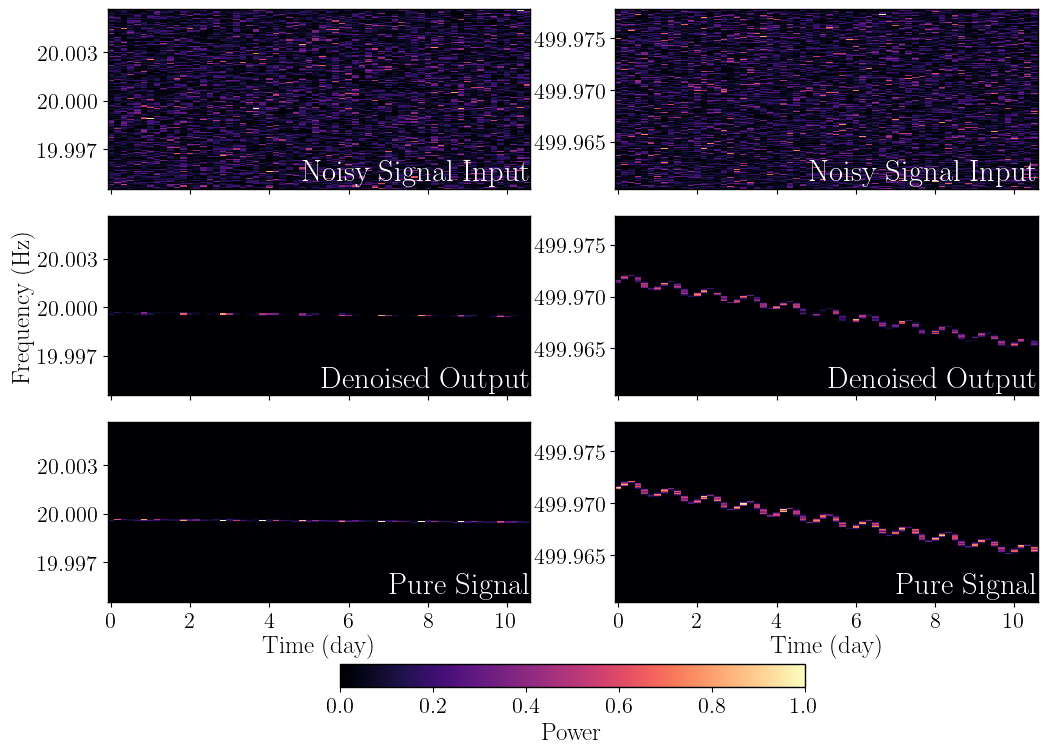

In [71]:
# Example usage
# 20 Hz data
idx_20 = 5
size = (512, 64)
Tsft = 14400
freq20_idx =  300

timestamps_20 = np.arange(0, size[1]) * Tsft
fourier_data_20 = [
    data_20[idx_20][freq20_idx-80:freq20_idx+80, :, :2],  # Noisy Signal Input
    predictions_20[idx_20].transpose(1, 2, 0)[freq20_idx-80:freq20_idx+80, :, :2],  # Denoised Output
    normalize(targets_20)[idx_20][freq20_idx-80:freq20_idx+80, :, :2]  # Pure Signal
]

# 500 Hz data
idx_500 = 351
freq500_idx = 260
timestamps_500 = np.arange(0, size[1]) * Tsft
fourier_data_500 = [
    data_500[idx_500][freq500_idx-125:freq500_idx+125, :, :2],  # Noisy Signal Input
    predictions_500[idx_500].transpose(1, 2, 0)[freq500_idx-125:freq500_idx+125, :, :2],  # Denoised Output
    normalize(targets_500)[idx_500][freq500_idx-125:freq500_idx+125, :, :2]  # Pure Signal
]

# Combine data
title = 'H1 Spectrograms'
subtitles = ['Noisy Signal Input', 'Denoised Output', 'Pure Signal']
main_titles = ['Spectrograms at 20 Hz', 'Spectrograms at 500 Hz']
fourier_data_lists = [fourier_data_20, fourier_data_500]
timestamps_list = [timestamps_20, timestamps_500]
frequency_list = [frequency_20[idx_20][freq20_idx-80:freq20_idx+80], frequency_500[idx_500][freq500_idx-125:freq500_idx+125]]

fig, ax = plot_combined_spectrograms(title, timestamps_list, frequency_list, fourier_data_lists, subtitles, main_titles)
fig.savefig('./result/plots/combined_20Hz_500Hz_spectrograms.pdf', dpi=300, bbox_inches='tight')
#plt.show()

In [50]:
f0 = 20
train_level = 32

max_train_levels = [20]
duty_factor = 0.75

# Model version
version = f'H1L1_a1b1_{f0}Hz_D{train_level}-{train_level}_T10_f512xTsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x64_MSELoss_dropout0'

# Load validation data (targets and masks)
filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_idx4.npz'
val_data = np.load(filename, allow_pickle=True)
targets_20 = val_data['clean_image']
frequency_20 = val_data['crop_freqs']
masks = new_mask(normalize(targets_20))  # Assuming new_mask and normalize are defined in utils

# Load model
model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
best_val_model = torch.load(f"../trained_model/{f0}Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False)
model.load_state_dict(best_val_model)

# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets_20.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    
    data = noise + targets_20
    data = normalize(data)
    data_20 = apply_duty_factor(data, duty_factor, size)  # Apply duty factor
    data_loader = load_dataset(data_20, batch_size=batch_size, shuffle=False)
    
    # Compute predictions
    predictions_20, inputs, ground_truth = [], [], []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions_20.append(outputs.cpu().numpy())
            
    predictions_20 = np.concatenate(predictions_20, axis=0)

Processing Sn=20: 100%|██████████| 125/125 [00:05<00:00, 23.16it/s]


In [51]:
f0 = 500
train_level = 22

# Model version
version = f'H1L1_a1b1_{f0}Hz_D{train_level}-{train_level}_T10_f512xTsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x64_MSELoss_dropout0'

# Load validation data (targets and masks)
filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_idx4.npz'
val_data = np.load(filename, allow_pickle=True)
targets_500 = val_data['clean_image']
frequency_500 = val_data['crop_freqs']
masks = new_mask(normalize(targets_500))  # Assuming new_mask and normalize are defined in utils

# Load model
model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
best_val_model = torch.load(f"../trained_model/{f0}Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False)
model.load_state_dict(best_val_model)


# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets_500.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    
    data = noise + targets_500
    data = normalize(data)
    data_500 = apply_duty_factor(data, duty_factor, size)  # Apply duty factor
    data_loader = load_dataset(data_500, batch_size=batch_size, shuffle=False)
    
    # Compute predictions
    predictions_500, inputs, ground_truth = [], [], []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions_500.append(outputs.cpu().numpy())
            
    predictions_500 = np.concatenate(predictions_500, axis=0)

Processing Sn=20: 100%|██████████| 125/125 [00:05<00:00, 24.16it/s]


Input shape for Spectrograms at 20 Hz: (160, 64, 2)
Number of zero columns in data (Spectrograms at 20 Hz): 16
Input shape for Spectrograms at 500 Hz: (250, 64, 2)
Number of zero columns in data (Spectrograms at 500 Hz): 16
Number of NaN columns in dataset 0,0 (Spectrograms at 20 Hz - Noisy Signal Input): 16
Number of NaN columns in dataset 0,1 (Spectrograms at 20 Hz - Denoised Output): 16
Number of NaN columns in dataset 0,2 (Spectrograms at 20 Hz - Pure Signal): 16
Number of NaN columns in dataset 1,0 (Spectrograms at 500 Hz - Noisy Signal Input): 16
Number of NaN columns in dataset 1,1 (Spectrograms at 500 Hz - Denoised Output): 16
Number of NaN columns in dataset 1,2 (Spectrograms at 500 Hz - Pure Signal): 16


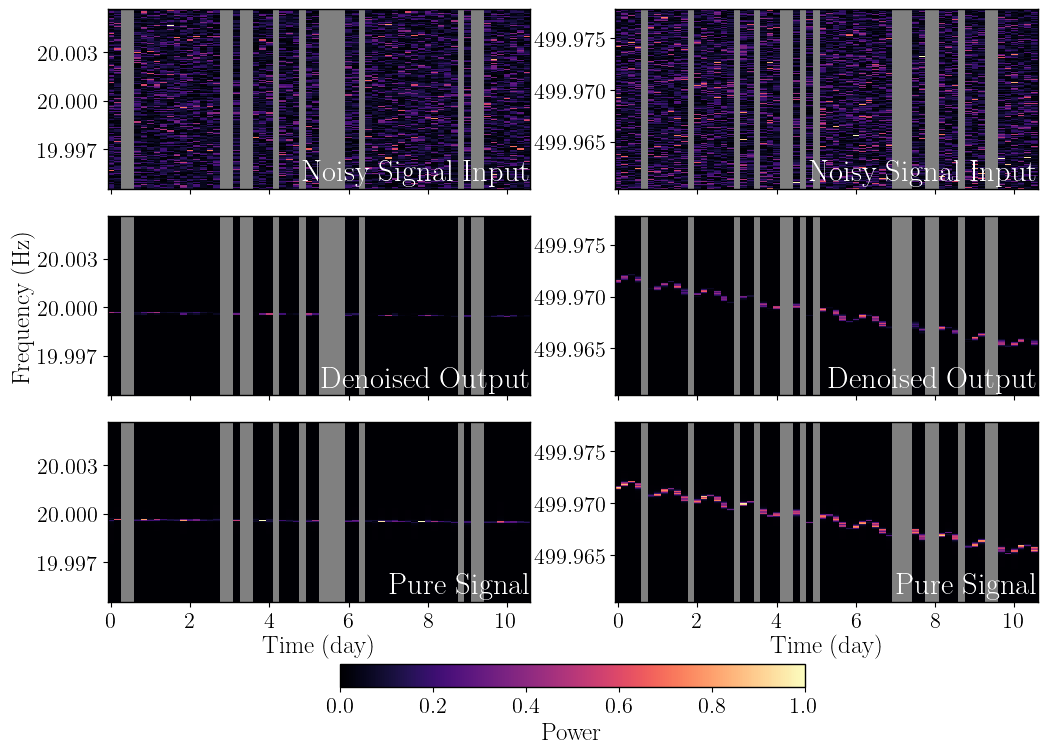

In [52]:
# Example usage
# 20 Hz data
idx_20 = 5
size = (512, 64)
Tsft = 14400
freq20_idx =  300

timestamps_20 = np.arange(0, size[1]) * Tsft
fourier_data_20 = [
    data_20[idx_20][freq20_idx-80:freq20_idx+80, :, :2],  # Noisy Signal Input
    predictions_20[idx_20].transpose(1, 2, 0)[freq20_idx-80:freq20_idx+80, :, :2],  # Denoised Output
    normalize(targets_20)[idx_20][freq20_idx-80:freq20_idx+80, :, :2]  # Pure Signal
]

# 500 Hz data
idx_500 = 351
freq500_idx = 260
timestamps_500 = np.arange(0, size[1]) * Tsft
fourier_data_500 = [
    data_500[idx_500][freq500_idx-125:freq500_idx+125, :, :2],  # Noisy Signal Input
    predictions_500[idx_500].transpose(1, 2, 0)[freq500_idx-125:freq500_idx+125, :, :2],  # Denoised Output
    normalize(targets_500)[idx_500][freq500_idx-125:freq500_idx+125, :, :2]  # Pure Signal
]

# Combine data
title = 'H1 Spectrograms'
subtitles = ['Noisy Signal Input', 'Denoised Output', 'Pure Signal']
main_titles = ['Spectrograms at 20 Hz', 'Spectrograms at 500 Hz']
fourier_data_lists = [fourier_data_20, fourier_data_500]
timestamps_list = [timestamps_20, timestamps_500]
frequency_list = [frequency_20[idx_20][freq20_idx-80:freq20_idx+80], frequency_500[idx_500][freq500_idx-125:freq500_idx+125]]

fig, ax = plot_combined_spectrograms(title, timestamps_list, frequency_list, fourier_data_lists, subtitles, main_titles)
fig.savefig('./result/plots/combined_20Hz_500Hz_spectrograms_gaps.pdf', dpi=300, bbox_inches='tight')
#plt.show()